# Analyzing all eight planets in the Solar System

In [1]:
# Importing crap
%load_ext autoreload
%autoreload 2

import sys
sys.path.append('../..')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm
import numexpr

import astropy.units as u
import astropy.constants as c

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (10, 8)
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['figure.labelsize'] = 14
plt.rcParams['xtick.labelsize'] = 12
plt.rcParams['ytick.labelsize'] = 12
plt.rcParams['legend.fontsize'] = 12
plt.rcParams['mathtext.fontset'] = 'cm'

In [14]:
# Distance to source plane
D_s = 8 * u.kpc

# Distance to lens plane
D_l = 4 * u.kpc

theta_ein, r_ein = IRSF.IRSFunctions.e_ring([D_s, D_l], 1)
print(f'Einstein ring radius: {r_ein}')
print(f'Einstein ring angle: {theta_ein}')

planets = ['Mercury', 'Venus', 'Earth', 'Mars', 'Jupiter', 'Saturn', 'Uranus', 'Neptune']

# Defining semimajor axes
r_mercury = 0.387
r_venus = 0.723
r_earth = 1
r_mars = 1.524
r_jupiter = 5.2
r_saturn = 9.5
r_uranus = 19.2
r_neptune = 30.07

planet_semimajor_axes = np.array([r_mercury, r_venus, r_earth, r_mars, r_jupiter, r_saturn, r_uranus, r_neptune]) * u.au # au

# Calculating in terms of theta_E
planet_ss = (planet_semimajor_axes / r_ein).to(u.dimensionless_unscaled).value # theta_E

# Defining masses
m_mercury = 0.330103e24
m_venus = 4.86731e24
m_earth = 5.97217e24
m_mars = 0.641691e24
m_jupiter = 1898.125e24
m_saturn = 568.317e24
m_uranus = 86.8099e24
m_neptune = 102.4092e24

planet_masses = np.array([m_mercury, m_venus, m_earth, m_mars, m_jupiter, m_saturn, m_uranus, m_neptune]) * u.kg # kg

# Calculating in terms of M_sun
planet_qs = (planet_masses / c.M_sun).to(u.dimensionless_unscaled).value # dimensionless

# Defining shears
planet_shears = []
for i in range(len(planets)):
    q = planet_qs[i]
    s = planet_ss[i]
    if s < 1:
        planet_shears.append(q * s**2)
    else:
        planet_shears.append(q * (1/s)**2)

planet_shears = np.array(planet_shears)

# Defining planet angles
seed = 2
np.random.seed(seed)
planet_alphas = np.random.uniform(0, 360, len(planets))

# Adding all attributes to a Pandas DataFrame
planet_attributes = pd.DataFrame({
    'Planet': planets,
    'Semimajor Axis [au]': planet_semimajor_axes,
    's': planet_ss,
    'Mass [kg]': planet_masses,
    'q': planet_qs,
    'Shear': planet_shears,
    'Angle [deg]': planet_alphas
})

# Changing Mercury's properties for testing
planet_attributes.loc[0, 'q'] = 2.357392042097786e-07
planet_attributes.loc[0, 's'] = 0.07683837479958969
planet_attributes.loc[0, 'Angle [deg]'] = 198.287245

planet_attributes

Einstein ring radius: 4.035803086556719 AU
Einstein ring angle: 1.0089507716391797 mas


,Planet,Semimajor Axis [au],s,Mass [kg],q,Shear,Angle [deg]
0,Mercury,0.387,0.076838,3.301030e+23,2.357392e-07,1.526531e-09,198.287245
1,Venus,0.723,0.179147,4.867310e+24,2.447840e-06,7.855969e-08,9.333443
2,Earth,1.000,0.247782,5.972170e+24,3.003490e-06,1.844023e-07,197.878492
3,Mars,1.524,0.377620,6.416910e+23,3.227157e-07,4.601824e-08,156.716061
4,Jupiter,5.200,1.288467,1.898125e+27,9.545944e-04,5.750057e-04,151.332409
5,Saturn,9.500,2.353931,5.683170e+26,2.858148e-04,5.158192e-05,118.920536
6,Uranus,19.200,4.757417,8.680990e+25,4.365795e-05,1.928949e-06,73.673508
7,Neptune,30.070,7.450810,1.024092e+26,5.150306e-05,9.277397e-07,222.937548


In [15]:
# Sorting planets by shear
planet_attributes = planet_attributes.sort_values(by='Shear', ascending=False)

planet_attributes

,Planet,Semimajor Axis [au],s,Mass [kg],q,Shear,Angle [deg]
4,Jupiter,5.200,1.288467,1.898125e+27,9.545944e-04,5.750057e-04,151.332409
5,Saturn,9.500,2.353931,5.683170e+26,2.858148e-04,5.158192e-05,118.920536
6,Uranus,19.200,4.757417,8.680990e+25,4.365795e-05,1.928949e-06,73.673508
7,Neptune,30.070,7.450810,1.024092e+26,5.150306e-05,9.277397e-07,222.937548
2,Earth,1.000,0.247782,5.972170e+24,3.003490e-06,1.844023e-07,197.878492
1,Venus,0.723,0.179147,4.867310e+24,2.447840e-06,7.855969e-08,9.333443
3,Mars,1.524,0.377620,6.416910e+23,3.227157e-07,4.601824e-08,156.716061
0,Mercury,0.387,0.076838,3.301030e+23,2.357392e-07,1.526531e-09,198.287245


Defining lens attributes

In [16]:
lens_att = []
lens_att.append([0, 0, 1])

for i in range(len(planets)):
    lens_att.append([planet_attributes['s'].iloc[i] * np.cos(np.deg2rad(planet_attributes['Angle [deg]'].iloc[i])), planet_attributes['s'].iloc[i] * np.sin(np.deg2rad(planet_attributes['Angle [deg]'].iloc[i])), planet_attributes['q'].iloc[i]])

lens_att = np.array(lens_att)

lens_att

array([[ 0.00000000e+00,  0.00000000e+00,  1.00000000e+00],
       [-1.13052389e+00,  6.18112867e-01,  9.54594436e-04],
       [-1.13835168e+00,  2.06037479e+00,  2.85814815e-04],
       [ 1.33735982e+00,  4.56557657e+00,  4.36579506e-05],
       [-5.45471262e+00, -5.07549727e+00,  5.15030636e-05],
       [-2.35816687e-01, -7.60689695e-02,  3.00349042e-06],
       [ 1.76774820e-01,  2.90539472e-02,  2.44784039e-06],
       [-3.46865588e-01,  1.49268668e-01,  3.22715658e-07],
       [-7.29576799e-02, -2.41104290e-02,  2.35739204e-07]])

Showing planet configuration

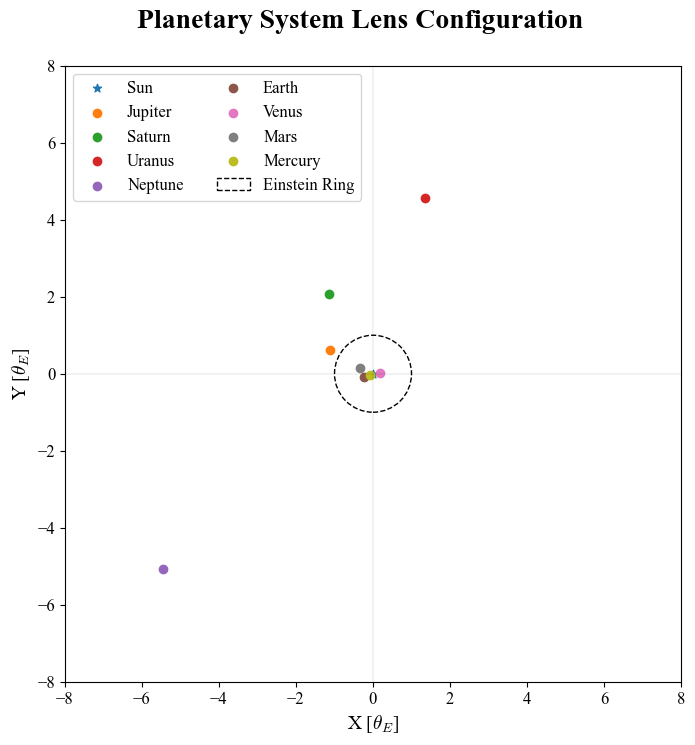

In [17]:
fig = plt.figure()
ax = fig.add_subplot()

fig.suptitle('Planetary System Lens Configuration', y=0.95)

for i in range(lens_att.shape[0]):
    ax.scatter(lens_att[i, 0], lens_att[i, 1], label=planet_attributes['Planet'].iloc[i-1] if i != 0 else 'Sun', marker='*' if i == 0 else 'o')

ring_patch = patches.Circle((0, 0), radius=1, fill=None, edgecolor='black', linestyle='--', label='Einstein Ring')
ax.add_patch(ring_patch)

ax.set_aspect('equal')

ax.set_xlabel(r'X [$\theta_E$]')
ax.set_ylabel(r'Y [$\theta_E$]')

view = 8
ax.set_xlim(-view, view)
ax.set_ylim(-view, view)
ax.hlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)
ax.vlines(0, -view, view, colors='black', linestyles='dashed', linewidth=0.1)

ax.legend(ncol=2, loc='best')

# fig.savefig('Lens Configuration.png', dpi=300)

plt.show()

Creating magnification maps

Binary offset: [0.00046193 0.        ]
4    Jupiter
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
Annulus bounds: y+ = 1.1281839134688458, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1671896, num_theta = 417974, Total number of rays: 6.988e+11


100%|██████████| 500/500 [00:02<00:00, 241.51it/s]


---------------------
Total time: 2.074 seconds
Plotting magnification map: 0.014 seconds


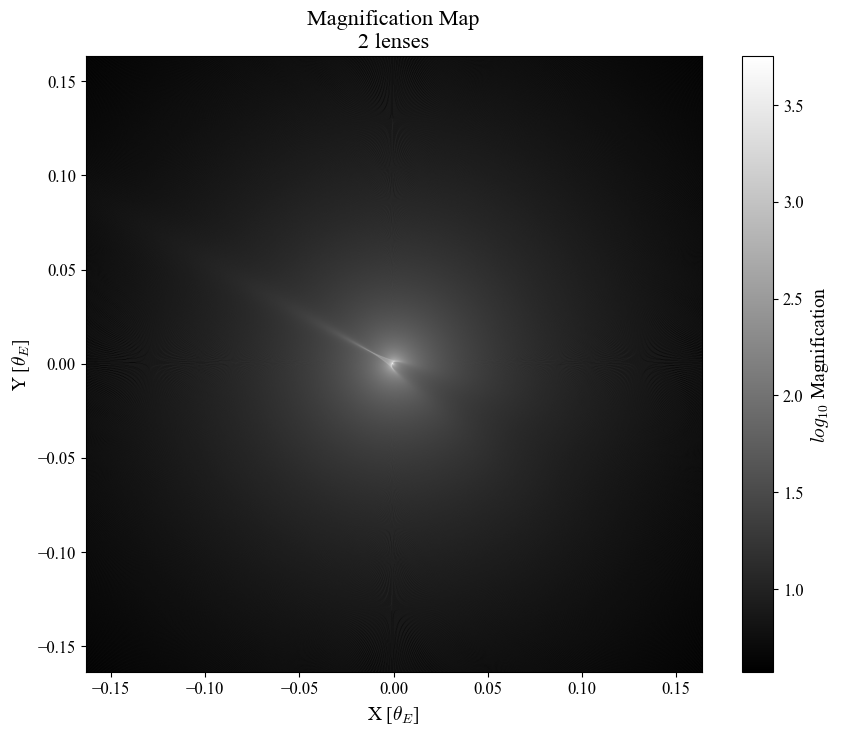

4    Jupiter
5     Saturn
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
Annulus bounds: y+ = 1.128504454996557, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673132, num_theta = 418283, Total number of rays: 6.998e+11


100%|██████████| 500/500 [00:02<00:00, 229.31it/s]


---------------------
Total time: 2.184 seconds
Plotting magnification map: 0.013 seconds


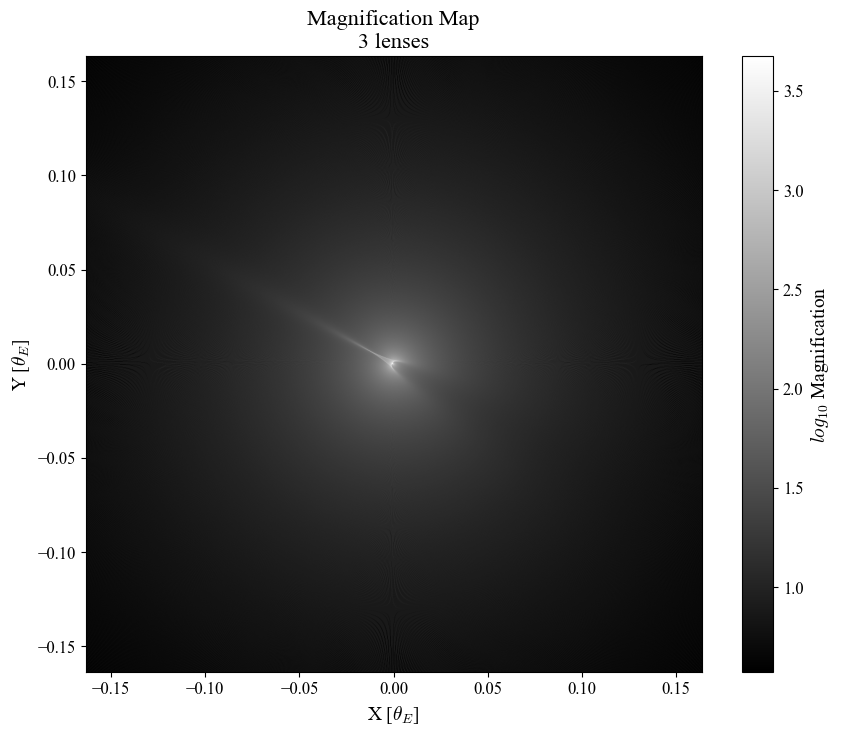

4    Jupiter
5     Saturn
6     Uranus
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
q = 4.365795064652567e-05, s = 4.757417442876562
Annulus bounds: y+ = 1.1286246028063949, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673596, num_theta = 418399, Total number of rays: 7.002e+11


100%|██████████| 500/500 [00:02<00:00, 219.36it/s]


---------------------
Total time: 2.283 seconds
Plotting magnification map: 0.014 seconds


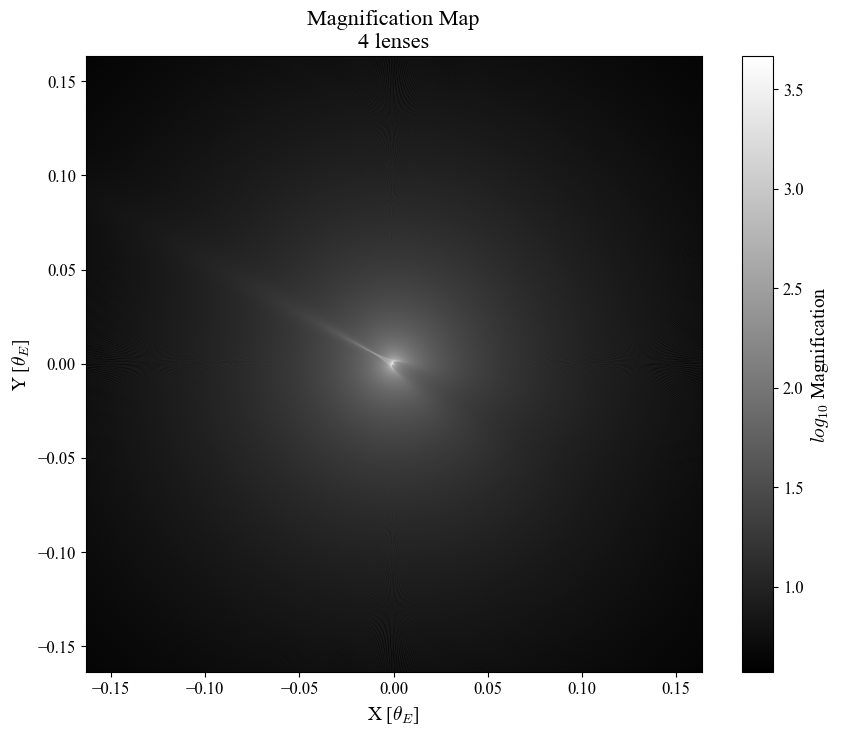

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
q = 4.365795064652567e-05, s = 4.757417442876562
q = 5.150306358318782e-05, s = 7.450809505588449
Annulus bounds: y+ = 1.1286246028063949, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673596, num_theta = 418399, Total number of rays: 7.002e+11


100%|██████████| 500/500 [00:02<00:00, 204.22it/s]


---------------------
Total time: 2.452 seconds
Plotting magnification map: 0.013 seconds


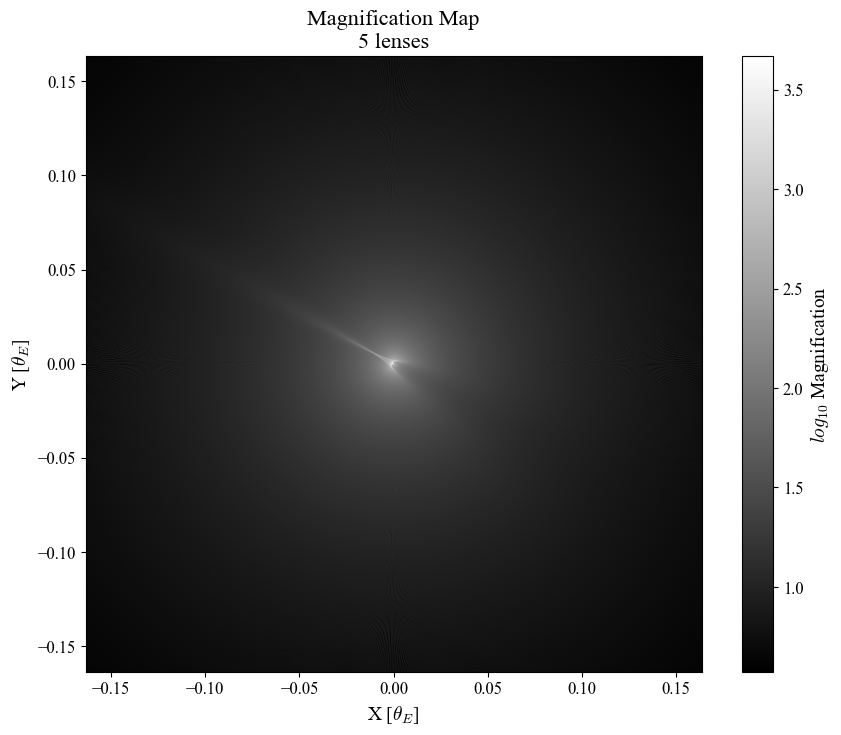

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
q = 4.365795064652567e-05, s = 4.757417442876562
q = 5.150306358318782e-05, s = 7.450809505588449
q = 3.0034904211692584e-06, s = 0.24778215848315427
Annulus bounds: y+ = 1.1286462721248667, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673680, num_theta = 418420, Total number of rays: 7.003e+11


100%|██████████| 500/500 [00:02<00:00, 196.31it/s]


---------------------
Total time: 2.55 seconds
Plotting magnification map: 0.015 seconds


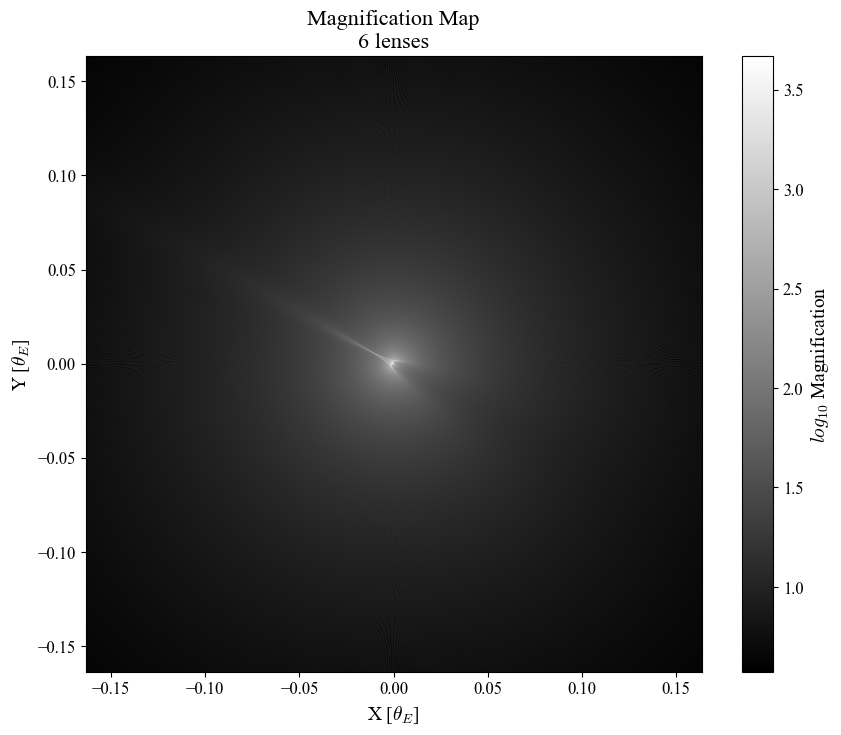

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
1      Venus
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
q = 4.365795064652567e-05, s = 4.757417442876562
q = 5.150306358318782e-05, s = 7.450809505588449
q = 3.0034904211692584e-06, s = 0.24778215848315427
q = 2.447840393334641e-06, s = 0.17914650058332052
Annulus bounds: y+ = 1.128646272125348, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673680, num_theta = 418420, Total number of rays: 7.003e+11


100%|██████████| 500/500 [00:02<00:00, 192.37it/s]


---------------------
Total time: 2.603 seconds
Plotting magnification map: 0.013 seconds


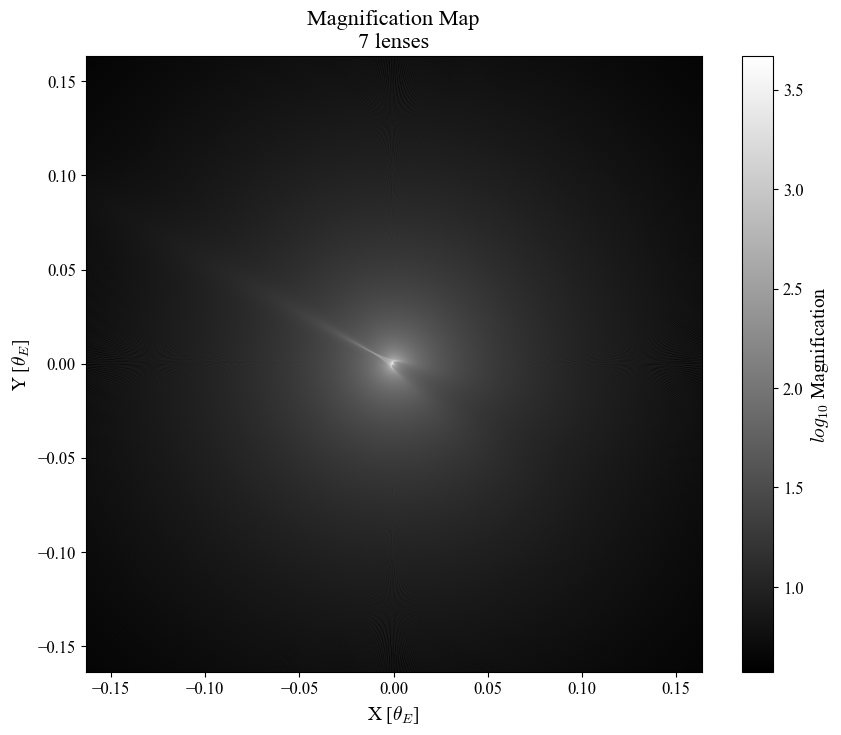

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
1      Venus
3       Mars
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
q = 4.365795064652567e-05, s = 4.757417442876562
q = 5.150306358318782e-05, s = 7.450809505588449
q = 3.0034904211692584e-06, s = 0.24778215848315427
q = 2.447840393334641e-06, s = 0.17914650058332052
q = 3.2271565810258627e-07, s = 0.3776200095283271
Annulus bounds: y+ = 1.128646272125567, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673680, num_theta = 418420, Total number of rays: 7.003e+11


100%|██████████| 500/500 [00:02<00:00, 191.37it/s]


---------------------
Total time: 2.616 seconds
Plotting magnification map: 0.013 seconds


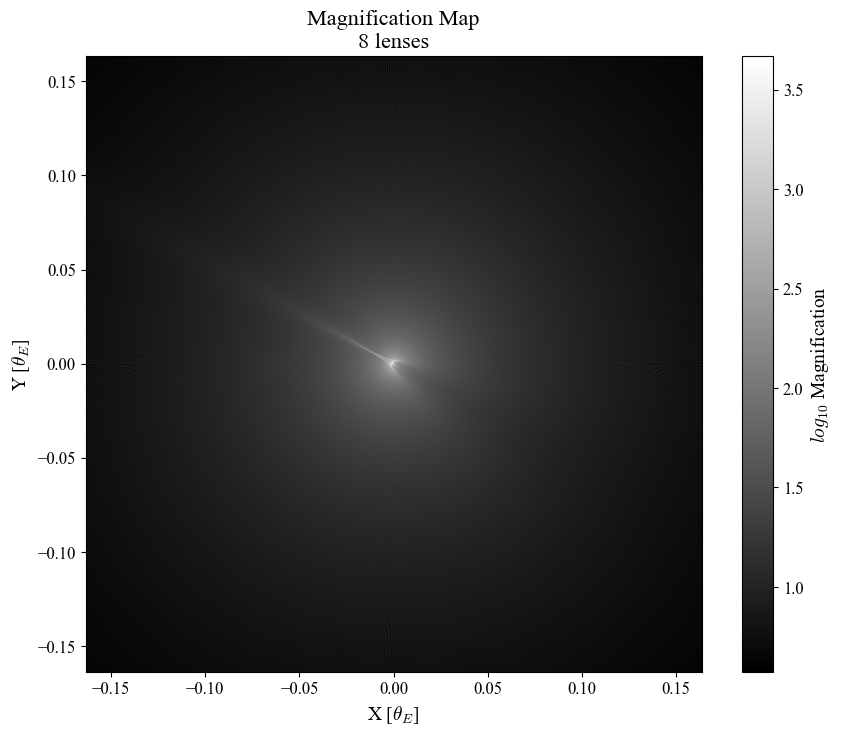

4    Jupiter
5     Saturn
6     Uranus
7    Neptune
2      Earth
1      Venus
3       Mars
0    Mercury
Name: Planet, dtype: object
Pixels = 4494, Angular Width = 0.32678984450436005, Max Source Radius = 0.07272995205159102, Min Source Radius = 0.0007272995205159103
q = 0.0009545944364748323, s = 1.2884672241124022
q = 0.00028581481533306144, s = 2.3539305055899655
q = 4.365795064652567e-05, s = 4.757417442876562
q = 5.150306358318782e-05, s = 7.450809505588449
q = 3.0034904211692584e-06, s = 0.24778215848315427
q = 2.447840393334641e-06, s = 0.17914650058332052
q = 3.2271565810258627e-07, s = 0.3776200095283271
q = 2.357392042097786e-07, s = 0.07683837479958969
Annulus bounds: y+ = 1.1286462721255888, y- = 0.8855425658962278, Min Magnification in Annulus = 4.152340572757894
Number of rays: num_r = 1673680, num_theta = 418420, Total number of rays: 7.003e+11


100%|██████████| 500/500 [00:02<00:00, 184.47it/s]


---------------------
Total time: 2.714 seconds
Plotting magnification map: 0.013 seconds


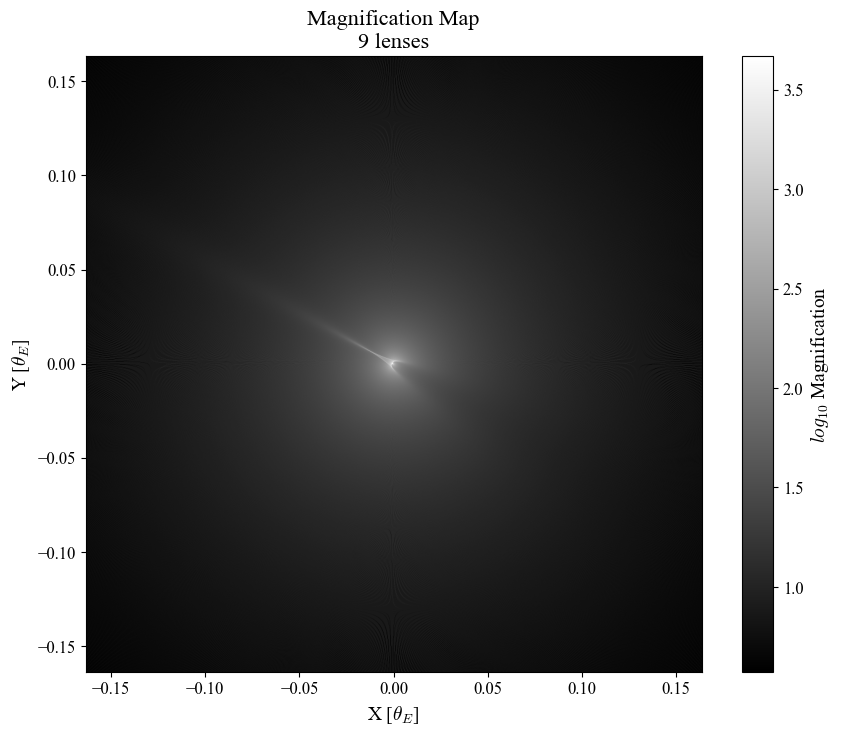

In [18]:
center_of_magnification = np.array([planet_attributes['q'].iloc[0] / ((1 + planet_attributes['q'].iloc[0]) * (planet_attributes['s'].iloc[0] + 1/planet_attributes['s'].iloc[0])), 0])
print(f'Binary offset: {center_of_magnification}')

lens_att[:, :2] -= center_of_magnification

# Iterating over all planets and consecutively creating magnification maps
for i in range(len(planets)):
    current_lens_att = lens_att[0:i+2, :]
    current_planets = planet_attributes['Planet'].iloc[0:i+1]
    print(current_planets)

    pixels, ang_width, (qs, ss), cusp_points, (max_source_radius, min_source_radius) = IRSF.IRSFunctions._ang_width_calculator(current_lens_att, final_multiplier=1, pixels_in_small_source=20, cm_offset='auto')
    print(f'Pixels = {pixels}, Angular Width = {ang_width}, Max Source Radius = {max_source_radius}, Min Source Radius = {min_source_radius}')

    (y_plus, y_minus), min_mag = IRSF.IRSFunctions._annulus_bounds_calculator(ang_width, qs, ss)
    print(f'Annulus bounds: y+ = {y_plus}, y- = {y_minus}, Min Magnification in Annulus = {min_mag}')

    num_r, num_theta = IRSF.IRSFunctions._num_ray_calculator(pixels, ang_width, y_plus, y_minus, min_mag, delta=0.01, r_theta_ratio=4)
    print(f'Number of rays: num_r = {num_r}, num_theta = {num_theta}, Total number of rays: {(num_r * num_theta):.3e}')

    lens_parameters = {
        'pixels': 1000,
        'ang_width': ang_width,
        'thickness': y_plus - y_minus,
        'y_plus': y_plus,
        'y_minus': y_minus,
        'lens_att': current_lens_att.tolist(),
        'num_theta': 5000,
        'num_r': 20000
    }
    
    sim_current_lens = IRSC.IRSCaustics(annulus_param_dict=lens_parameters)
    magnifications_current_lens = sim_current_lens.series_calculate(cm_offset='auto')
    sim_current_lens.plot()

    plt.show()

In [7]:
f'{current_planets.str.join("_")}.pkl'

'4    J_u_p_i_t_e_r\n5      S_a_t_u_r_n\n6      U_r_a_n_u_s\n7    N_e_p_t_u_n_e\n2        E_a_r_t_h\n1        V_e_n_u_s\n3          M_a_r_s\n0    M_e_r_c_u_r_y\nName: Planet, dtype: object.pkl'

In [ ]:
file_name = current_planets.iloc[0]
for i, planet in enumerate(current_planets.values):
    if i != 0:
        file_name += f'_{planet}'

file_name += '.pkl'

file_name

'Jupiter_Saturn_Uranus_Neptune_Earth_Venus_Mars_Mercury.pkl'